## Chapter 10 Making predications by interpolation and extrapolation

Interpolation refers to the process of generating data points between already existing data points. Extrapolation is the process of generating points outside a given set of known data points.
(inter and extra are derived from Latin words meaning 'between' and 'outside' respectively) [click here](https://plotly.com/python/v3/interpolation-and-extrapolation-in-1d/)
It is rarely to find interpolate/extrapolate chapter in a book for beginners or intermediate in Python course. However, the likelihood of confronting interpolation problem in your computing life should be above the 99% and that's why I feel that we must go through this together so you will rememember me later 😄.

As always there are several ways and modules for a such task in Python. In that chapter, we will discuss through examples three ways of doing interpolation.

## `scipy.interpolate.interp1d`
class `scipy.interpolate.interp1d(x, y, kind='linear', axis=- 1, copy=True, bounds_error=None, fill_value=nan, assume_sorted=False)[source]`

x and y are arrays of values used to approximate some function f: y = f(x). This class returns a function whose call method uses interpolation to find the value of new points.

The most important input values in this function are the following:
* x(N,) array_like: A 1-D array of real values.
* y(…,N,…) array_like: A N-D array of real values. The length of y along the interpolation axis must be equal to the length of x.
* kind: str or int, optional Specifies the kind of interpolation as a string (‘linear’, ‘nearest’, ‘zero’, ‘slinear’, ‘quadratic’, ‘cubic’, ‘previous’, ‘next’, where ‘zero’, ‘slinear’, ‘quadratic’ and ‘cubic’ refer to a spline interpolation of zeroth, first, second or third order; ‘previous’ and ‘next’ simply return the previous or next value of the point) or as an integer specifying the order of the spline interpolator to use. Default is ‘linear’.
* fill_value: array-like or (array-like, array_like) or “extrapolate”, optional: this value will be used to fill in for requested points outside of the data range. If not provided, then the default is NaN.

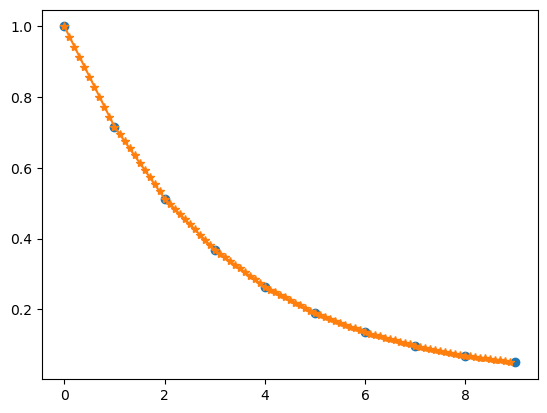

In [1]:
import matplotlib.pyplot as plt
from scipy import interpolate
import numpy as np

x = np.arange(0, 10)
y = np.exp(-x/3.0)
f = interpolate.interp1d(x, y)


xnew = np.arange(0, 9, 0.1)
ynew = f(xnew)   # use interpolation function returned by `interp1d`

plt.plot(x, y, 'o', xnew, ynew, '-*')
plt.show()

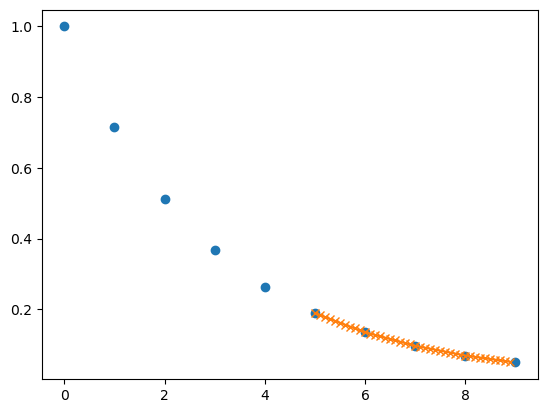

In [8]:
import matplotlib.pyplot as plt
from scipy import interpolate
import numpy as np

x = np.arange(0, 10)
y = np.exp(-x/3.0)
f = interpolate.interp1d(x, y, kind = 'linear')


xnew = np.arange(5, 9, 0.1)
ynew = f(xnew)

plt.plot(x, y, 'o', xnew, ynew, '-x')
plt.show()

We can use the attribute `fill_value= 'extrapolate'` for extrapolation.

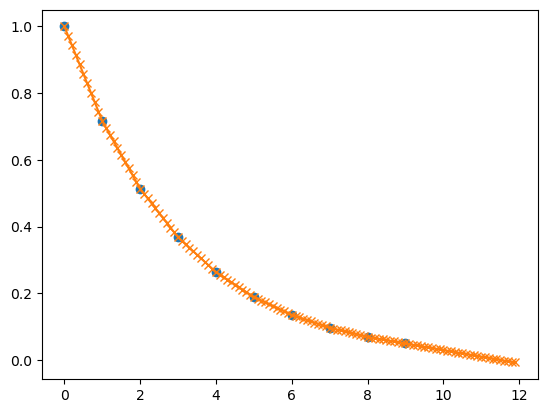

In [10]:
import matplotlib.pyplot as plt
from scipy import interpolate
import numpy as np

x = np.arange(0, 10)
y = np.exp(-x/3.0)
f = interpolate.interp1d(x, y, kind = 'linear', fill_value= 'extrapolate')


xnew = np.arange(0, 12, 0.1)
ynew = f(xnew)

plt.plot(x, y, 'o', xnew, ynew, '-x')
plt.show()

If a two-element tuple, then the first element is used as a fill value for x_new < x[0] and the second element is used for x_new > x[-1]. In that case, remember to disable the bounds error using the attribute `bounds_error=False`:

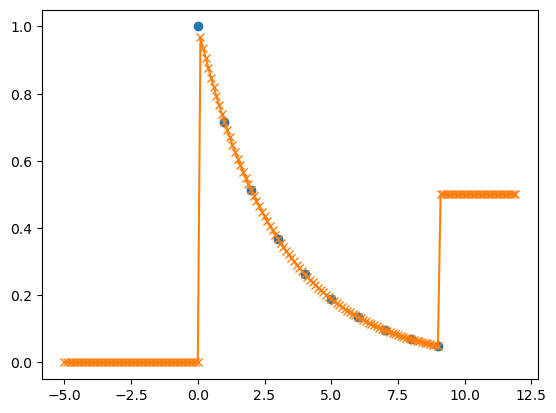

In [14]:
import matplotlib.pyplot as plt
from scipy import interpolate
import numpy as np

x = np.arange(0, 10)
y = np.exp(-x/3.0)
f = interpolate.interp1d(x, y, kind = 'cubic', fill_value= (0,0.5)\
                         ,bounds_error=False)


xnew = np.arange(-5, 12, 0.1)
ynew = f(xnew)

plt.plot(x, y, 'o', xnew, ynew, '-x')
plt.show()

## numpy.interp:
 numpy.interp(x, xp, fp, left=None, right=None, period=None)[source]

One-dimensional linear interpolation.
Returns the one-dimensional piecewise linear interpolant to a function with given discrete data points (xp, fp), evaluated at x.

***Parameters***:

* x: array_like. The x-coordinates at which to evaluate the interpolated values.
* xp: 1-D sequence of floats. The x-coordinates of the data points, must be increasing if argument period is not specified. Otherwise, xp is internally sorted after normalizing the periodic boundaries with xp = xp % period.
* fp: 1-D sequence of float or complex. The y-coordinates of the data points, same length as xp.
* left: optional float or complex corresponding to fp:         Value to return for x < xp[0], default is fp[0].   
* right: optional float or complex corresponding to fp
: Value to return for x > xp[-1], default is fp[-1].

***Returns***: y: float or complex (corresponding to fp) or ndarray. The interpolated values, same shape as x.



In [5]:
xp = np.arange(0, 10)
fp = np.exp(-x/3.0)
np.interp(11, xp, fp)

0.049787068367863944

Extrapolation with specific values:

In [6]:
xp = np.arange(0, 10)
fp = np.exp(-x/3.0)
print(np.interp(-1, xp, fp, left = 0, right = 1))
print(np.interp(11, xp, fp, left = 0, right = 1))


0.0
1.0


Another example of intrpolation to the sine function:

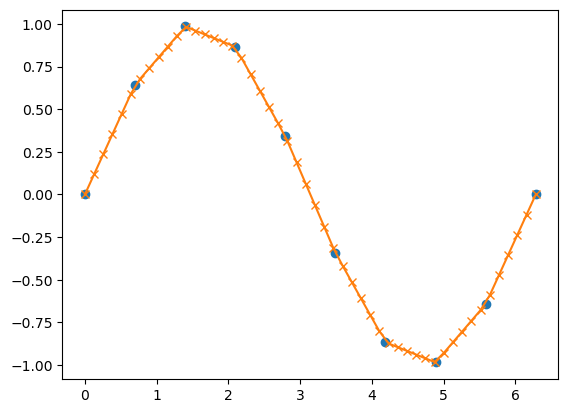

In [7]:
x = np.linspace(0, 2*np.pi, 10)
y = np.sin(x)

xvals = np.linspace(0, 2*np.pi, 50)
yinterp = np.interp(xvals, x, y)

import matplotlib.pyplot as plt

plt.plot(x, y, 'o')
plt.plot(xvals, yinterp, '-x')

plt.show()

I don't recomend this method because it is limited to the linear interpolation method.

## `pandas.DataFrame.interpolate`

DataFrame.interpolate(method='linear', axis=0, limit=None, inplace=False, limit_direction=None, limit_area=None, downcast=None, **kwargs)
***Parameters:
* method: str, default 'linear': But we can use others like nearest’, ‘zero’, ‘slinear’, ‘quadratic’, ‘cubic’, ‘spline’, ‘barycentric’, ‘polynomial’: Passed to scipy.interpolate.interp1d. These methods use the numerical values of the index. Both ‘polynomial’ and ‘spline’ require that you also specify an order (int), e.g. `df.interpolate(method='polynomial', order=5).`

In [8]:
import pandas as pd
import numpy as np
s = pd.Series([0, 1, np.nan, 3])
print(s)
s.interpolate()

0    0.0
1    1.0
2    NaN
3    3.0
dtype: float64


0    0.0
1    1.0
2    2.0
3    3.0
dtype: float64

In [9]:
import pandas as pd
s = pd.Series([0, 1, np.nan, 3])
print(s)
s.interpolate(method='polynomial',order = 2)

0    0.0
1    1.0
2    NaN
3    3.0
dtype: float64


0    0.0
1    1.0
2    2.0
3    3.0
dtype: float64

In [18]:
import numpy as np
import pandas as pd


exam_data  = {'name': ['Anastasia', 'Dima', 'Katherine', 'James', 'Emily', 'Michael', 'Matthew', 'Laura', 'Kevin', 'Jonas'],

        'score': [12.5, 9, 16.5, np.nan, 9, 20, 14.5, np.nan, 8, 19],

        'attempts': [1, 3, 2, 3, 2, 3, 1, 1, 2, 1],

        'qualify': ['yes', 'no', 'yes', 'no', 'no', 'yes', 'yes', 'no', 'no', 'yes']}

labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']

df = pd.DataFrame(exam_data , index=labels)
print(df)

df = df.interpolate(method='linear')
print(df)

        name  score  attempts qualify
a  Anastasia   12.5         1     yes
b       Dima    9.0         3      no
c  Katherine   16.5         2     yes
d      James    NaN         3      no
e      Emily    9.0         2      no
f    Michael   20.0         3     yes
g    Matthew   14.5         1     yes
h      Laura    NaN         1      no
i      Kevin    8.0         2      no
j      Jonas   19.0         1     yes
        name  score  attempts qualify
a  Anastasia  12.50         1     yes
b       Dima   9.00         3      no
c  Katherine  16.50         2     yes
d      James  12.75         3      no
e      Emily   9.00         2      no
f    Michael  20.00         3     yes
g    Matthew  14.50         1     yes
h      Laura  11.25         1      no
i      Kevin   8.00         2      no
j      Jonas  19.00         1     yes


In [24]:
import pandas as pd
import numpy as np
pd.set_option('display.max_rows', None)
#pd.set_option('display.max_columns', None)
df = pd.DataFrame({
'ord_no':[70001,np.nan,70002,70004,np.nan,70005,np.nan,70010,70003,70012,np.nan,70013],
'purch_amt':[150.5,np.nan,65.26,110.5,948.5,np.nan,5760,1983.43,np.nan,250.45, 75.29,3045.6],
'sale_amt':[10.5,20.65,np.nan,11.5,98.5,np.nan,57,19.43,np.nan,25.45, 75.29,35.6],
'ord_date': ['2012-10-05','2012-09-10',np.nan,'2012-08-17','2012-09-10','2012-07-27','2012-09-10','2012-10-10','2012-10-10','2012-06-27','2012-08-17','2012-04-25'],
'customer_id':[3002,3001,3001,3003,3002,3001,3001,3004,3003,3002,3001,3001],
'salesman_id':[5002,5003,5001,np.nan,5002,5001,5001,np.nan,5003,5002,5003,np.nan]})
print("Original Orders DataFrame:")
print(df) 

'''
df['ord_no'] = df['ord_no'].interpolate(method='linear')
df['purch_amt'] = df['purch_amt'].interpolate(method='polynomial',order=2)
df['sale_amt'] = df['sale_amt'].interpolate(method='spline',order=2)
df['ord_date'] = df['ord_date'].interpolate(method='linear', direction='forward')
df['salesman_id'] = df['salesman_id'].interpolate(method='linear', direction='forward')
'''

#df = df.interpolate(method='polynomial',order=2)
df = df.interpolate(method='linear')
print(df)

Original Orders DataFrame:
     ord_no  purch_amt  sale_amt    ord_date  customer_id  salesman_id
0   70001.0     150.50     10.50  2012-10-05         3002       5002.0
1       NaN        NaN     20.65  2012-09-10         3001       5003.0
2   70002.0      65.26       NaN         NaN         3001       5001.0
3   70004.0     110.50     11.50  2012-08-17         3003          NaN
4       NaN     948.50     98.50  2012-09-10         3002       5002.0
5   70005.0        NaN       NaN  2012-07-27         3001       5001.0
6       NaN    5760.00     57.00  2012-09-10         3001       5001.0
7   70010.0    1983.43     19.43  2012-10-10         3004          NaN
8   70003.0        NaN       NaN  2012-10-10         3003       5003.0
9   70012.0     250.45     25.45  2012-06-27         3002       5002.0
10      NaN      75.29     75.29  2012-08-17         3001       5003.0
11  70013.0    3045.60     35.60  2012-04-25         3001          NaN
     ord_no  purch_amt  sale_amt    ord_date  cust

## 2D Interpolation Methods

In this section, we will extend the 1D interpolation methods into two dimensions. Instead of having a single set of known values and interpolation points, we now have a 2D grid of known data points, and we want to interpolate those values over a new 2D grid.

We will cover three common interpolation techniques in 2D:
- **Nearest-Neighbor Interpolation**: A fast but less smooth interpolation method.
- **Bilinear Interpolation**: A linear interpolation performed first along one axis, then along the other.
- **Bicubic Interpolation**: A smooth interpolation technique that fits a cubic function in both directions.

In each case, we have:
- Known grids of $X$, $Y$ coordinates: `X_known`, `Y_known`.
- Known function values: `Z_known`.
- We aim to interpolate over new grids: `X_interp`, `Y_interp` to get `Z_interp`.

In [1]:
def plot_image(image_1, image_2,title_1="Orignal",title_2="New Image"):
    plt.figure(figsize=(10,10))
    plt.subplot(1, 2, 1)
    plt.imshow(image_1,cmap="gray")
    plt.title(title_1)
    plt.subplot(1, 2, 2)
    plt.imshow(image_2,cmap="gray")
    plt.title(title_2)
    plt.show()

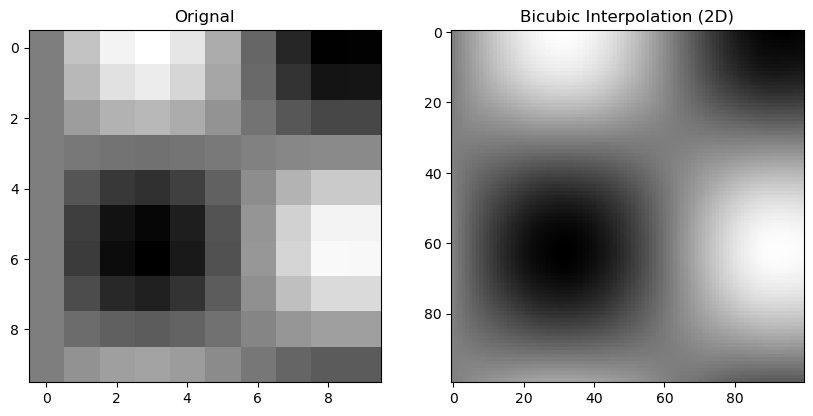

'\nplt.figure()\nplt.imshow(Z_interp, extent=(0, 5, 0, 5), origin=\'lower\', cmap=\'viridis\')\nplt.colorbar()\nplt.title("Bicubic Interpolation (2D)")\nplt.xlabel(\'x\')\nplt.ylabel(\'y\')\nplt.show()\n'

In [15]:
# Bicubic Interpolation Example in 2D

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Create a 2D grid of known values (a simple surface)
x_known = np.linspace(0, 5, 10)
y_known = np.linspace(0, 5, 10)
X_known, Y_known = np.meshgrid(x_known, y_known)
Z_known = np.sin(X_known) * np.cos(Y_known)

# Define interpolation grid (higher resolution)
x_interp = np.linspace(0, 5, 100)
y_interp = np.linspace(0, 5, 100)
X_interp, Y_interp = np.meshgrid(x_interp, y_interp)

# Perform bicubic interpolation (method='cubic')
Z_interp = griddata((X_known.flatten(), Y_known.flatten()), Z_known.flatten(), (X_interp, Y_interp), method='cubic')

# Plot the result
plot_image(Z_known, Z_interp,title_1="Orignal",title_2="Bicubic Interpolation (2D)")
'''
plt.figure()
plt.imshow(Z_interp, extent=(0, 5, 0, 5), origin='lower', cmap='viridis')
plt.colorbar()
plt.title("Bicubic Interpolation (2D)")
plt.xlabel('x')
plt.ylabel('y')
plt.show()
'''